# 04 - Model Interpretability with SHAP and LIME

This notebook explains model behavior at two levels:
1. Global patterns (SHAP summary)
2. Local case-level explanations (LIME)

Interpretability is used here to inspect model logic and detect unstable dependence patterns.

In [20]:
%pip install shap lime xgboost

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Install if needed:
# %pip install shap lime xgboost

from pathlib import Path
import numpy as np
import pandas as pd

import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer

DATASET_DIR = Path('../dataset')

In [22]:
train = pd.read_csv(DATASET_DIR / 'train.csv').fillna(0)
features = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]
X = train[features]
y = train['time_to_hit_hours'] * np.where(train['event'] == 1, 1, -1)

model = xgb.XGBRegressor(
    objective='survival:cox',
    n_estimators=120,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X, y)
print('trained rows:', len(X))

trained rows: 221


## SHAP Global Explanations

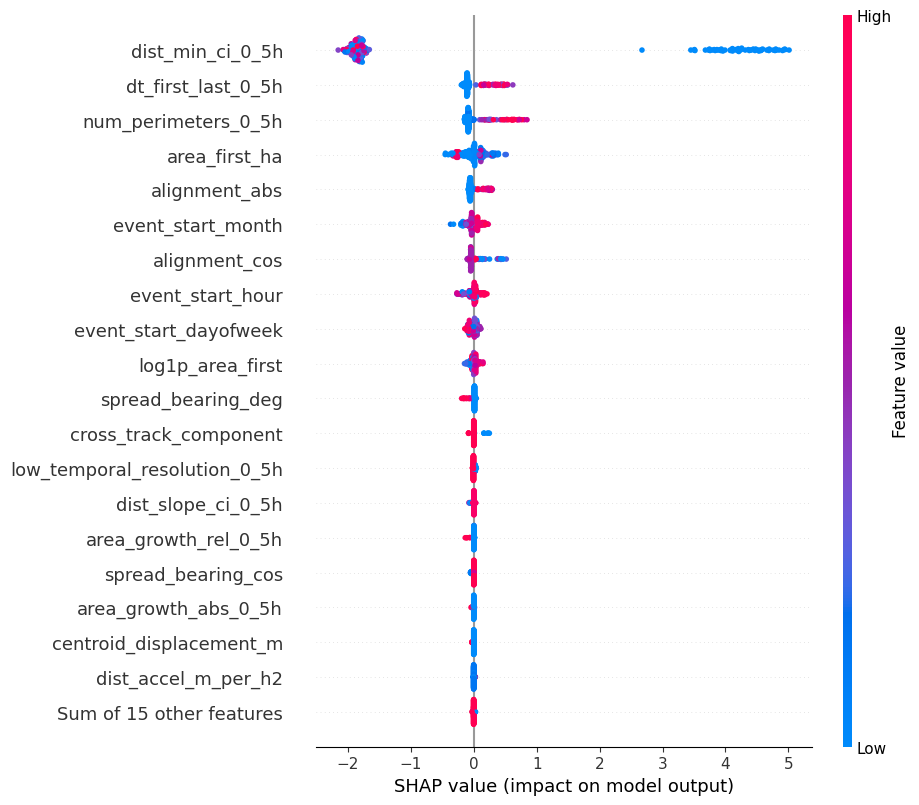

In [23]:
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.plots.beeswarm(shap_values, max_display=20)

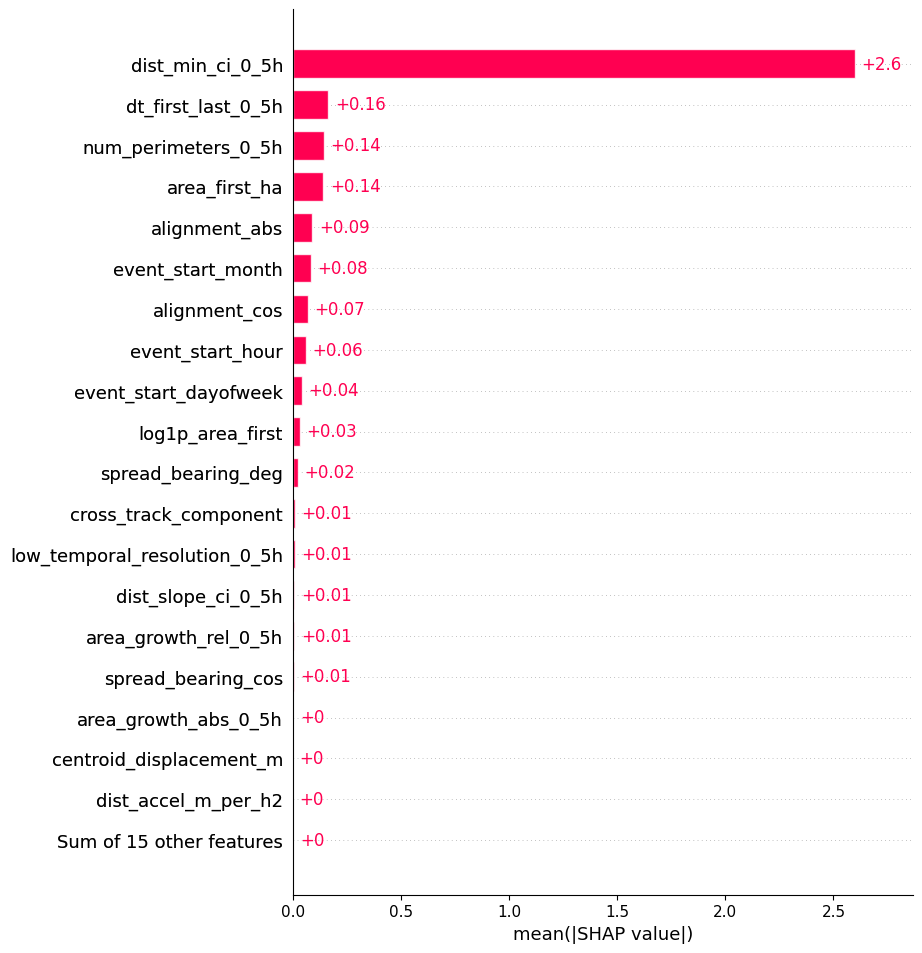

In [24]:
shap.plots.bar(shap_values, max_display=20)

## LIME Local Explanation

In [25]:
explainer_lime = LimeTabularExplainer(
    training_data=X.values,
    feature_names=features,
    mode='regression',
    random_state=42
)

row_idx = 0
exp = explainer_lime.explain_instance(
    data_row=X.iloc[row_idx].values,
    predict_fn=lambda z: model.predict(pd.DataFrame(z, columns=features)),
    num_features=10
)

print('LIME explanation for row index:', row_idx)
for rule, weight in exp.as_list():
    print(f'{rule}: {weight:.4f}')

LIME explanation for row index: 0
num_perimeters_0_5h > 2.00: 8.1610
2965.22 < dist_min_ci_0_5h <= 31758.58: -5.0260
dt_first_last_0_5h > 1.36: 4.1927
event_start_month <= 6.00: -1.8202
alignment_cos <= 0.00: 1.7492
0.00 < alignment_abs <= 0.07: -1.6647
spread_bearing_deg > 0.00: -1.5854
9.00 < event_start_hour <= 19.00: -1.3082
along_track_speed <= 0.00: 1.2892
cross_track_component <= 0.00: 1.2731
